# Glucose Cluster Prediction — Machine Learning Models

This notebook trains and evaluates Random Forest and Neural Network 
models to predict daily glucose profile cluster membership from 
sleep physiological features and wrist temperature cluster labels.

## Objective
Predict whether a participant's day belongs to the high or low 
continuous glucose monitoring cluster based on sleep-derived features 
and thermoregulation patterns from the previous night.

## Input Features
- Normalized sleep features (_norm columns): HRV, respiratory rate,
  sleep stages, oxygen saturation, restlessness
- Wrist temperature cluster label from the previous night

## Models
- Random Forest (100 trees) trained on standardized features
- Neural Network (MLP: 32-16 units, ReLU, Adam)

## Interpretability
- SHAP applied to identify which sleep features most strongly 
  predict next-day glucose variability

## Key Finding
Sleep-derived physiological signals predict daily glucose profiles 
with strong performance (AUC > 0.87), suggesting that nocturnal 
wearable data captures metabolic information relevant to next-day 
glucose regulation.

Total samples: 1066
Features:      18
Class balance:
glucose_cluster
0    533
1    533

Train: 556 | Test: 510

RANDOM FOREST
                      precision    recall  f1-score   support

 Low glucose cluster       0.88      0.94      0.91       345
High glucose cluster       0.85      0.73      0.78       165

            accuracy                           0.87       510
           macro avg       0.86      0.83      0.84       510
        weighted avg       0.87      0.87      0.87       510

ROC AUC: 0.906

NEURAL NETWORK
                      precision    recall  f1-score   support

 Low glucose cluster       0.93      0.88      0.90       345
High glucose cluster       0.77      0.87      0.82       165

            accuracy                           0.87       510
           macro avg       0.85      0.87      0.86       510
        weighted avg       0.88      0.87      0.88       510

ROC AUC: 0.953


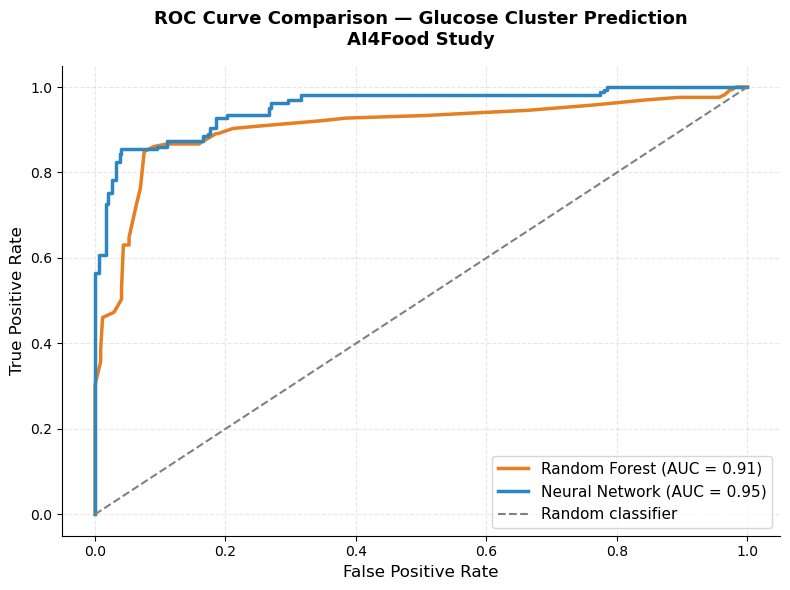

Figure saved: figures/glucose_model_roc.png


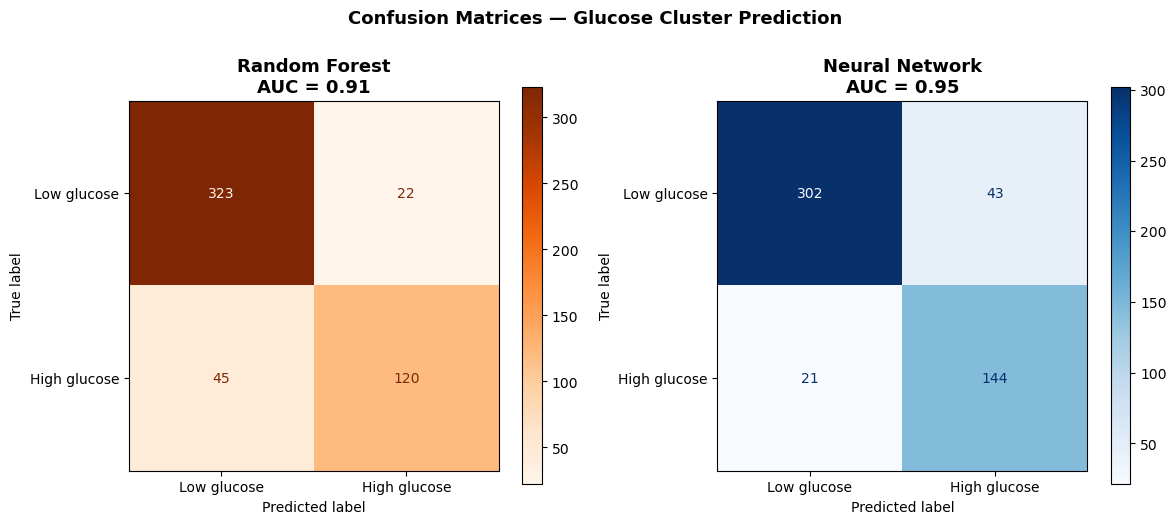

Figure saved: figures/glucose_model_confusion.png

Computing SHAP values...
SHAP values shape: (1066, 18)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_10968\1154725386.py:179: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


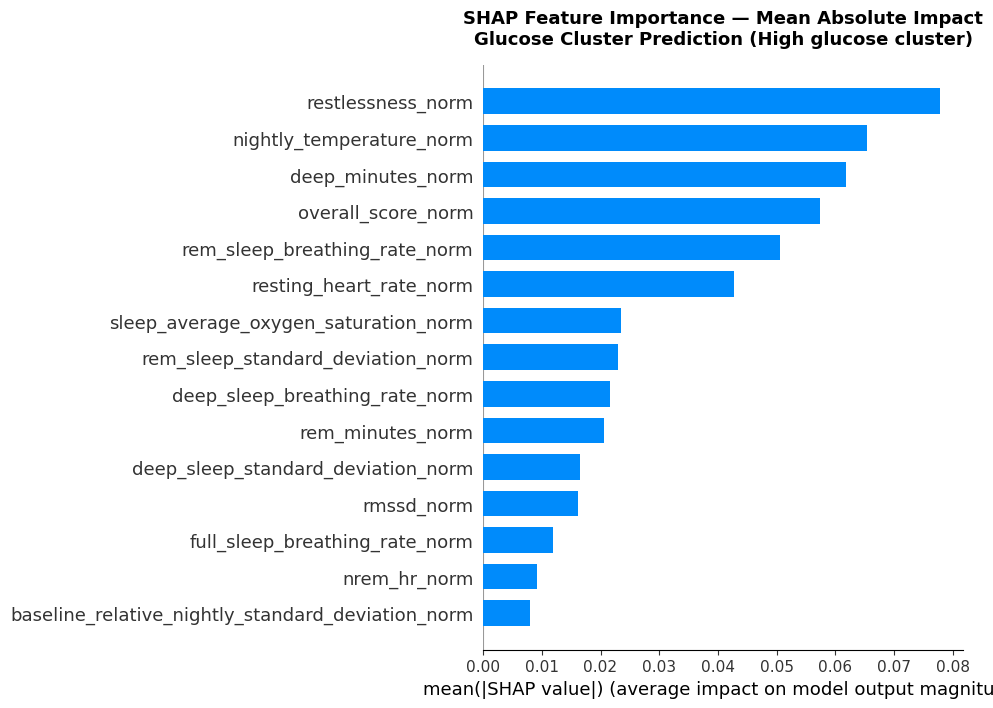

Figure saved: figures/glucose_shap_bar.png


C:\Users\ASUS\AppData\Local\Temp\ipykernel_10968\1154725386.py:198: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


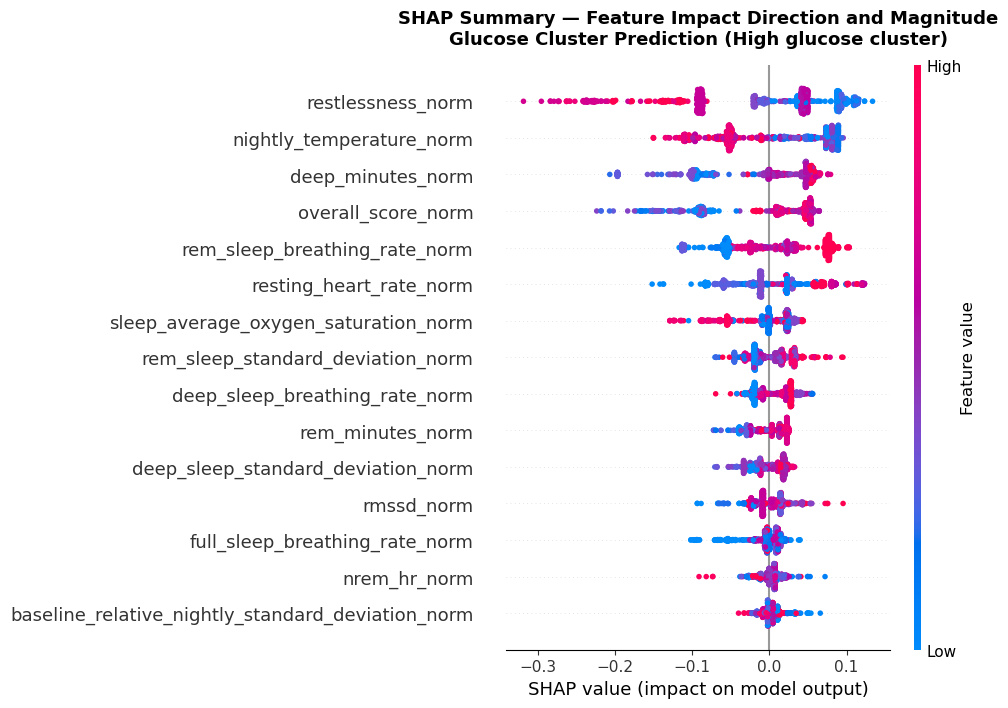

Figure saved: figures/glucose_shap_beeswarm.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
import os

np.random.seed(42)
os.makedirs("figures", exist_ok=True)

# CONFIGURATION

DATA_PATH  = "data/glucose_cluster_balanced_split.xlsx"
TARGET_COL = "glucose_cluster"
COLOR_RF   = "#E67E22"
COLOR_NN   = "#2E86C1"

# LOAD DATA

df = pd.read_excel(DATA_PATH)

norm_features  = [col for col in df.columns if col.endswith('_norm')]
input_features = norm_features + ['aligned_cluster_label']

print(f"Total samples: {len(df)}")
print(f"Features:      {len(input_features)}")
print(f"Class balance:\n{df[TARGET_COL].value_counts().to_string()}")

# TRAIN / TEST SPLIT

train_df = df[df['set'] == 'train']
test_df  = df[df['set'] == 'test']

X_train = train_df[input_features]
y_train = train_df[TARGET_COL]
X_test  = test_df[input_features]
y_test  = test_df[TARGET_COL]

print(f"\nTrain: {len(train_df)} | Test: {len(test_df)}")

# STANDARDIZE

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# TRAIN MODELS

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf  = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

nn = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
nn.fit(X_train_scaled, y_train)
y_pred_nn  = nn.predict(X_test_scaled)
y_proba_nn = nn.predict_proba(X_test_scaled)[:, 1]

auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_nn = roc_auc_score(y_test, y_proba_nn)

# EVALUATION SUMMARY

print("\n" + "="*50)
print("RANDOM FOREST")
print("="*50)
print(classification_report(y_test, y_pred_rf,
      target_names=["Low glucose cluster", "High glucose cluster"]))
print(f"ROC AUC: {auc_rf:.3f}")

print("\n" + "="*50)
print("NEURAL NETWORK")
print("="*50)
print(classification_report(y_test, y_pred_nn,
      target_names=["Low glucose cluster", "High glucose cluster"]))
print(f"ROC AUC: {auc_nn:.3f}")

# FIGURE 1 : ROC CURVE COMPARISON

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_nn)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_rf, tpr_rf, color=COLOR_RF, lw=2.5,
        label=f"Random Forest (AUC = {auc_rf:.2f})")
ax.plot(fpr_nn, tpr_nn, color=COLOR_NN, lw=2.5,
        label=f"Neural Network (AUC = {auc_nn:.2f})")
ax.plot([0, 1], [0, 1], color='gray', lw=1.5,
        linestyle='--', label='Random classifier')

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(
    "ROC Curve Comparison — Glucose Cluster Prediction\n"
    "AI4Food Study",
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figures/glucose_model_roc.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/glucose_model_roc.png")

# FIGURE 2 : CONFUSION MATRICES 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["Low glucose", "High glucose"],
    cmap="Oranges", ax=axes[0]
)
axes[0].set_title(f"Random Forest\nAUC = {auc_rf:.2f}",
                  fontsize=13, fontweight='bold')
axes[0].grid(False)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nn,
    display_labels=["Low glucose", "High glucose"],
    cmap="Blues", ax=axes[1]
)
axes[1].set_title(f"Neural Network\nAUC = {auc_nn:.2f}",
                  fontsize=13, fontweight='bold')
axes[1].grid(False)

plt.suptitle(
    "Confusion Matrices — Glucose Cluster Prediction",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig("figures/glucose_model_confusion.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/glucose_model_confusion.png")

# SHAP ANALYSIS

X_all = df[input_features]
y_all = df[TARGET_COL]

rf_full = RandomForestClassifier(n_estimators=100, random_state=42)
X_all_scaled = scaler.fit_transform(X_all)
rf_full.fit(X_all_scaled, y_all)

print("\nComputing SHAP values...")
explainer   = shap.TreeExplainer(rf_full)
shap_values = explainer.shap_values(X_all_scaled)

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_class1 = shap_values[:, :, 1]
elif isinstance(shap_values, list):
    shap_class1 = shap_values[1]
else:
    shap_class1 = shap_values

print(f"SHAP values shape: {shap_class1.shape}")

# FIGURE 3 : SHAP Bar Plot
plt.figure(figsize=(14, 8))
shap.summary_plot(
    shap_class1,
    pd.DataFrame(X_all_scaled, columns=input_features),
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title(
    "SHAP Feature Importance — Mean Absolute Impact\n"
    "Glucose Cluster Prediction (High glucose cluster)",
    fontsize=13, fontweight='bold', pad=15
)
plt.subplots_adjust(left=0.35, right=0.95, top=0.88, bottom=0.1)
plt.savefig("figures/glucose_shap_bar.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/glucose_shap_bar.png")

# FIGURE 4 : SHAP Beeswarm Plot
plt.figure(figsize=(16, 10))
shap.summary_plot(
    shap_class1,
    pd.DataFrame(X_all_scaled, columns=input_features),
    max_display=15,
    show=False
)
plt.title(
    "SHAP Summary — Feature Impact Direction and Magnitude\n"
    "Glucose Cluster Prediction (High glucose cluster)",
    fontsize=13, fontweight='bold', pad=15
)
plt.subplots_adjust(left=0.35, right=0.95, top=0.88, bottom=0.1)
plt.savefig("figures/glucose_shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/glucose_shap_beeswarm.png")